In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/gym_churn.csv")
df.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [3]:
# Convert date columns to datetime
df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors='coerce')
df['Last_Visit_Date'] = pd.to_datetime(df['Last_Visit_Date'], errors='coerce')

# Create membership duration feature
df['Membership_Duration_Days'] = (df['Last_Visit_Date'] - df['Join_Date']).dt.days

# Drop original date columns and irrelevant features
df = df.drop(['Member_ID', 'Name', 'Address', 'Phone_Number', 'Join_Date', 'Last_Visit_Date'], axis=1)

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (150, 10)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       137 non-null    float64
 1   Gender                    150 non-null    str    
 2   Membership_Type           150 non-null    str    
 3   Favorite_Exercise         150 non-null    str    
 4   Avg_Workout_Duration_Min  150 non-null    int64  
 5   Avg_Calories_Burned       139 non-null    float64
 6   Total_Weight_Lifted_kg    142 non-null    float64
 7   Visits_Per_Month          138 non-null    float64
 8   Churn                     150 non-null    str    
 9   Membership_Duration_Days  141 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 11.8 KB


In [5]:
df.describe()

,Age,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Membership_Duration_Days
count,137.000000,150.000000,139.000000,142.000000,138.000000,141.000000
mean,35.905109,73.326667,488.309353,9486.978873,14.224638,184.297872
std,11.654892,25.879560,168.649317,5127.955128,6.385451,115.394525
min,18.000000,30.000000,209.000000,1009.000000,4.000000,0.000000
25%,25.000000,53.000000,341.500000,5274.000000,8.000000,81.000000
50%,36.000000,74.000000,496.000000,9072.500000,14.000000,196.000000
75%,46.000000,94.500000,627.500000,13620.750000,20.000000,281.000000
max,54.000000,119.000000,788.000000,19722.000000,24.000000,399.000000


In [6]:
df.isnull().sum()

Age                         13
Gender                       0
Membership_Type              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
Membership_Duration_Days     9
dtype: int64

In [7]:
# Impute missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute numeric with mean
if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='mean')
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute categorical with most frequent
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

/tmp/ipykernel_21327/2346958491.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


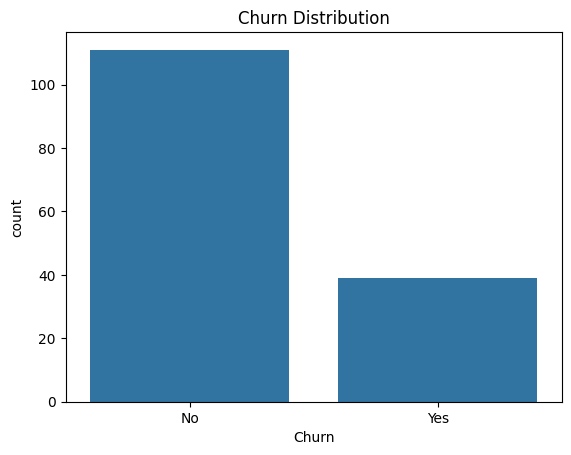

In [8]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.savefig("../results/figures/churn_distribution.png")
plt.show()

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

/tmp/ipykernel_21327/4134231849.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [11]:
# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Check class distribution
print("Churn distribution in training set:")
print(y_train.value_counts())

# Apply SMOTE if imbalanced
if y_train.value_counts().min() / y_train.value_counts().max() < 0.5:  # if minority class < 50% of majority
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("Applied SMOTE for class balancing")
else:
    print("Classes are balanced, no SMOTE applied")

Churn distribution in training set:
Churn
0    89
1    31
Name: count, dtype: int64
Applied SMOTE for class balancing


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, model in models.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True)
    
    results.append({
        "Model": name,
        "CV Accuracy Mean": cv_scores.mean(),
        "CV Accuracy Std": cv_scores.std(),
        "Test Accuracy": acc,
        "F1 Score": report["weighted avg"]["f1-score"]
    })
    
    print(f"\n{name}")
    print(f"CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
    print(classification_report(y_test, preds))


Logistic Regression
CV Accuracy: 0.944 (+/- 0.035)
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        22
           1       0.62      0.62      0.62         8

    accuracy                           0.80        30
   macro avg       0.74      0.74      0.74        30
weighted avg       0.80      0.80      0.80        30


Decision Tree
CV Accuracy: 0.978 (+/- 0.022)
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       1.00      0.62      0.77         8

    accuracy                           0.90        30
   macro avg       0.94      0.81      0.85        30
weighted avg       0.91      0.90      0.89        30


Random Forest
CV Accuracy: 0.972 (+/- 0.063)
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       1.00      0.62      0.77         8

    accuracy                          

In [15]:
results_df = pd.DataFrame(results)
results_df

,Model,CV Accuracy Mean,CV Accuracy Std,Test Accuracy,F1 Score
0,Logistic Regression,0.943968,0.017327,0.8,0.800000
1,Decision Tree,0.977619,0.011195,0.9,0.891653
2,Random Forest,0.971746,0.031301,0.9,0.891653


In [16]:
results_df.to_csv("../results/tables/model_comparison.csv", index=False)

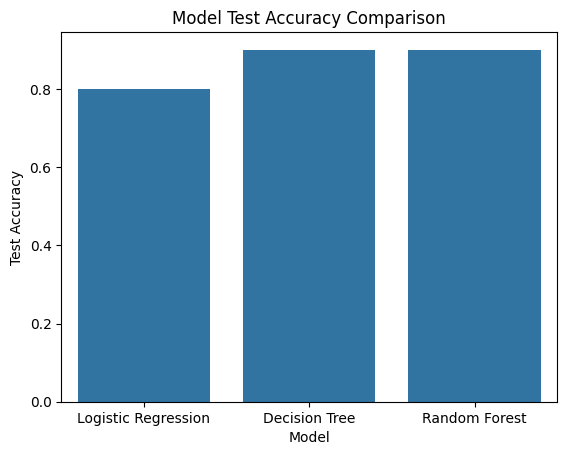

In [17]:
sns.barplot(x="Model", y="Test Accuracy", data=results_df)
plt.title("Model Test Accuracy Comparison")
plt.savefig("../results/figures/model_accuracy.png")
plt.show()

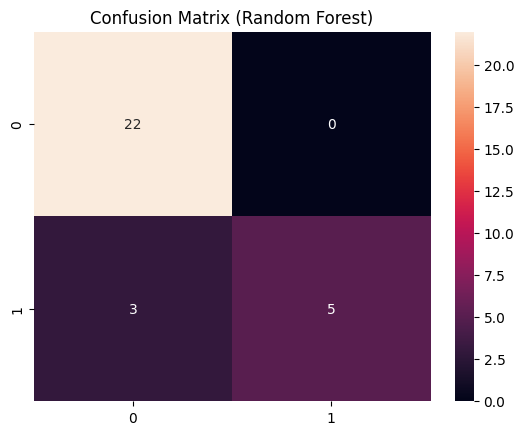

In [18]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Random Forest)")
plt.savefig("../results/figures/confusion_matrix.png")
plt.show()

In [ ]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Random Forest)")
plt.savefig("../results/figures/confusion_matrix.png")
plt.show()

In [19]:
importances = best_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_df

,Feature,Importance
7,Visits_Per_Month,0.731310
0,Age,0.048456
8,Membership_Duration_Days,0.045915
4,Avg_Workout_Duration_Min,0.036831
6,Total_Weight_Lifted_kg,0.033053
2,Membership_Type,0.032373
3,Favorite_Exercise,0.031269
5,Avg_Calories_Burned,0.027920
1,Gender,0.012874


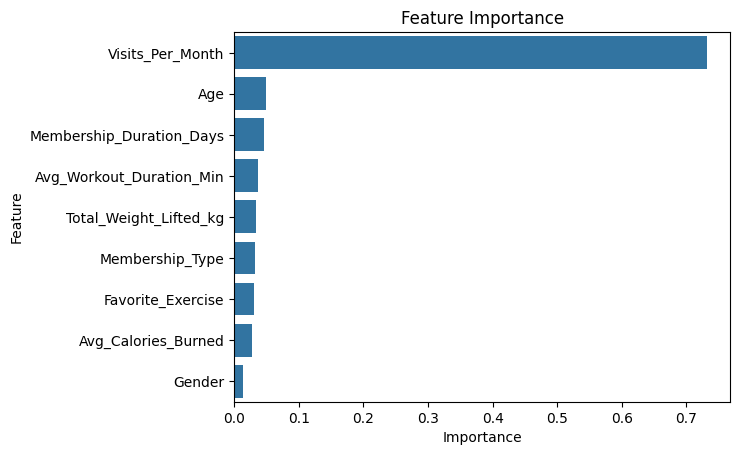

In [20]:
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.savefig("../results/figures/feature_importance.png")
plt.show()